In [475]:
import numpy as np #
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [476]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [477]:
df=pd.read_csv('/content/drive/MyDrive/2차 프로젝트/data/dataset.csv')

#결측치 처리함수 반영


In [478]:
df.isnull().sum()

,0
CustomerID,0
Churn,0
Tenure,264
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,251
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,255
NumberOfDeviceRegistered,0


In [479]:
# 앞선 조원의 결측치 처리 함수를 반영해 결측치 우선 처리

def fill_hour_spend_on_app(df):

    hour_spend_on_app_mode = df['HourSpendOnApp'].mode()[0]

    df['HourSpendOnApp'].fillna(hour_spend_on_app_mode, inplace=False)

    print(f"'HourSpendOnApp' 컬럼의 최빈값: {hour_spend_on_app_mode}")
    print(f"'HourSpendOnApp' 컬럼의 결측치 처리 후 남은 결측치 수: {df['HourSpendOnApp'].isnull().sum()}")

    return df

In [480]:
df = fill_hour_spend_on_app(df.copy())

'HourSpendOnApp' 컬럼의 최빈값: 3.0
'HourSpendOnApp' 컬럼의 결측치 처리 후 남은 결측치 수: 255


In [481]:

def fill_warehouse_to_home(df):

    WarehouseToHome_by_citytier_median = df.groupby('CityTier')['WarehouseToHome'].median()

    print("'CityTier'별 'WarehouseToHome' 중앙값:")
    print(WarehouseToHome_by_citytier_median)

    for tier, median_val in WarehouseToHome_by_citytier_median.items():
        df.loc[(df['CityTier'] == tier) & (df['WarehouseToHome'].isnull()), 'WarehouseToHome'] = median_val

    print("\n'WarehouseToHome' 컬럼의 결측치 처리 후:")
    print(df['WarehouseToHome'].isnull().sum())

    return df

In [482]:
df = fill_warehouse_to_home(df.copy())

'CityTier'별 'WarehouseToHome' 중앙값:
CityTier
1    13.0
2    13.0
3    14.0
Name: WarehouseToHome, dtype: float64

'WarehouseToHome' 컬럼의 결측치 처리 후:
0


In [483]:
def fill_coupon_used(df):

    df['CashbackPerOrder'] = df['CashbackAmount'] / df['OrderCount']

    df['CashbackPerOrder_quantile'] = pd.qcut(
        df['CashbackPerOrder'],
        q=4,
        labels=False,
        duplicates='drop'
    )

    median_coupon_used_per_quantile = df.groupby('CashbackPerOrder_quantile')['CouponUsed'].median()


    for q_label, median_val in median_coupon_used_per_quantile.items():
        df.loc[
            (df['CashbackPerOrder_quantile'] == q_label) & (df['CouponUsed'].isnull()),
            'CouponUsed'
        ] = median_val


    overall_median_coupon_used = df['CouponUsed'].median()
    df['CouponUsed'].fillna(overall_median_coupon_used, inplace=True)

    print("'CouponUsed' 컬럼의 결측치 처리 후:")
    print(df['CouponUsed'].isnull().sum())


    df.drop(columns=['CashbackPerOrder', 'CashbackPerOrder_quantile'], inplace=True)

    return df

In [484]:

df = fill_coupon_used(df.copy())


'CouponUsed' 컬럼의 결측치 처리 후:
0


/tmp/ipykernel_3266/489561014.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CouponUsed'].fillna(overall_median_coupon_used, inplace=True)


In [485]:
def fill_tenure(group, overall_median):
    if len(group) < 5:
        return group.fillna(overall_median)
    return group.fillna(group.median(),inplace=True)


def fill_day(group, overall_median):
    if len(group) < 5:
        return group.fillna(overall_median)
    return group.fillna(group.median(),inplace=True)


def fill_order_count(group, overall_median):
    if len(group) < 5:
        return group.fillna(overall_median)
    return group.fillna(group.median(),inplace=True)

def fill_hike(group, overall_median_hike):
    if len(group) < 5:
        return group.fillna(overall_median_hike)
    return group.fillna(group.median(),inplace=True)

def fill_hour(group, overall_median_hike):
    if len(group) < 5:
        return group.fillna(overall_median_hike)
    return group.fillna(group.median(),inplace=True)

In [486]:
fill_tenure(df['Tenure'],1), fill_day(df['DaySinceLastOrder'],1), fill_order_count(df['OrderCount'],1), fill_hike(df['OrderAmountHikeFromlastYear'],1), fill_hike(df['HourSpendOnApp'],1)

(None, None, None, None, None)

In [487]:
df.isnull().sum()

,0
CustomerID,0
Churn,0
Tenure,0
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,0
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,0
NumberOfDeviceRegistered,0


## 이상치 확인

In [488]:
# transaction_data.csv 완료

In [489]:
print(df.dtypes)
print(df.info())

CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                   int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       -------

In [490]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [491]:
df.describe(include='number')
# 수치형  Tenure WarehouseToHome	HourSpendOnApp NumberOfDeviceRegistered NumberOfAddress OrderAmountHikeFromlastYear OrderCount DaySinceLastOrder CashbackAmount
# 범주형	CustomerID Churn CityTier SatisfactionScore Complain CouponUsed PreferredLoginDevice	PreferredPaymentMode	Gender	PreferedOrderCat	MaritalStatus

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000
mean,52815.500000,0.168384,10.134103,1.654707,15.528774,2.934636,3.688988,3.066785,4.214032,0.284902,15.674600,1.753108,2.961812,4.459325,177.221492
std,1625.385339,0.374240,8.357951,0.915389,8.355284,0.705528,1.023999,1.380194,2.583586,0.451408,3.591058,1.861372,2.879248,3.570626,49.193869
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,3.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,52815.500000,0.000000,9.000000,1.000000,13.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,54222.750000,0.000000,15.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000


In [492]:
df.describe(include='object')

,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
count,5630,5630,5630,5630,5630
unique,3,7,2,6,3
top,Mobile Phone,Debit Card,Male,Laptop & Accessory,Married
freq,2765,2314,3384,2050,2986


In [493]:
#SMOTE 필요

## 이상치 처리

- 이상치란: 관측된 데이터의 일반적인 범위를 크게 벗어난 데이터

- 이상치 처리는 수치형데이터만 가능하며 범주형 데이터(수치형으로 보이는 순서형 데이터 포함)는 평균과 표준편차를 구할수 없기때문에\
 이상치 처리의 의미가 없다.

### Tenure


In [494]:
df['Tenure'].skew(),df['Tenure'].kurt() # 왜도(데이터 분포의 비대칭도) 및 첨도(확률분포의 뾰족한 부분)

(np.float64(0.7732782369506156), np.float64(0.15461343944830785))

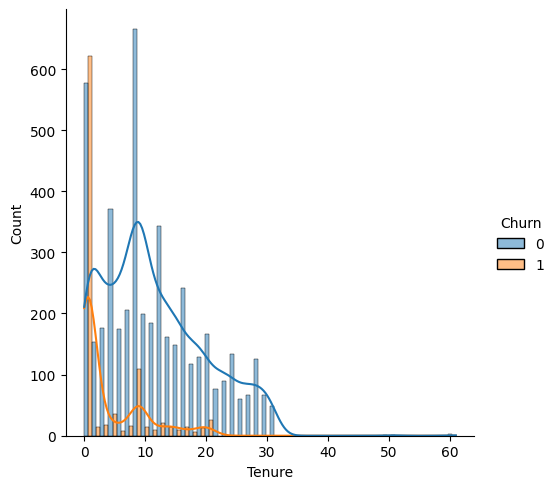

In [495]:
sns.displot(df, x="Tenure", hue="Churn", multiple="dodge", kde=True)

<Axes: ylabel='Tenure'>

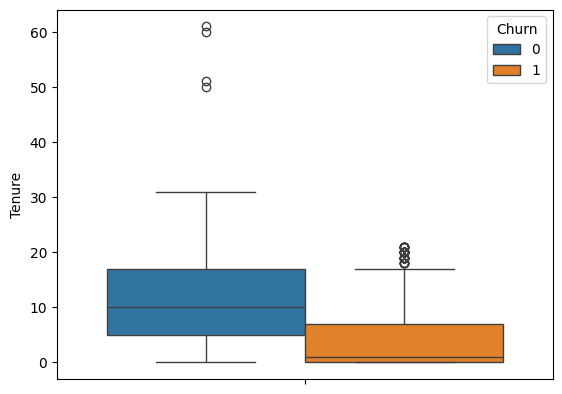

In [496]:
sns.boxplot(y=df['Tenure'],hue="Churn", data=df)

In [497]:
 df['Tenure1'] = np.log1p(df["Tenure"]) #logl1p함수를 이용해서 왜도 감소 및 정규성 확보

In [498]:
df['Tenure1'].skew(),df['Tenure1'].kurt()

(np.float64(-0.6393182984342735), np.float64(-0.6928308989058185))

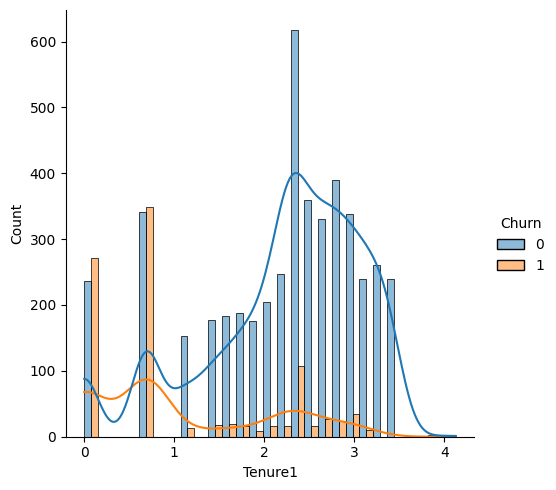

In [499]:
sns.displot(df, x="Tenure1", hue="Churn", multiple="dodge",kde=True)

<Axes: ylabel='Tenure1'>

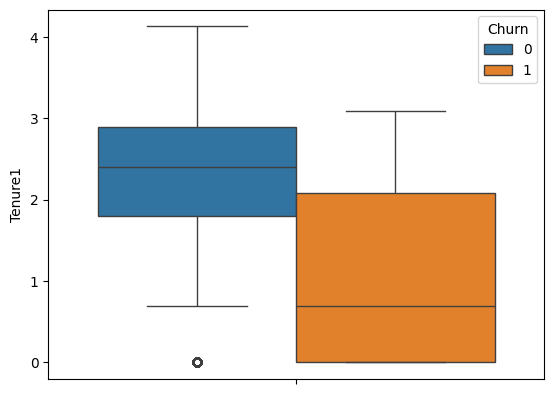

In [500]:
sns.boxplot(y=df['Tenure1'],hue="Churn", data=df)

In [501]:
# Tenure 이상치 해소

### WarehouseToHome

In [502]:
df['WarehouseToHome'].skew(),df['WarehouseToHome'].kurt()

(np.float64(1.68553525748992), np.float64(10.576530489284426))

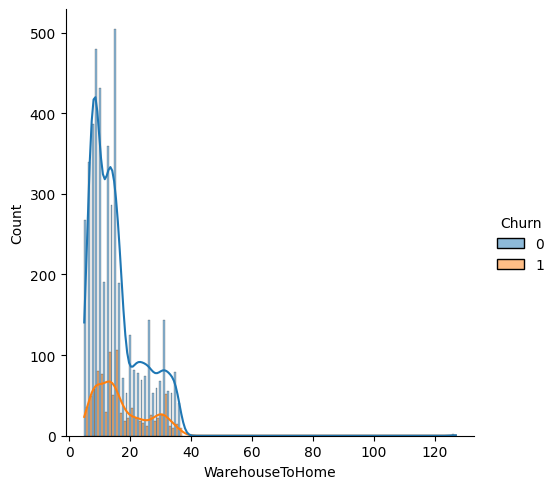

In [503]:
sns.displot(df, x="WarehouseToHome", hue="Churn", multiple="dodge",kde=True)


<Axes: ylabel='WarehouseToHome'>

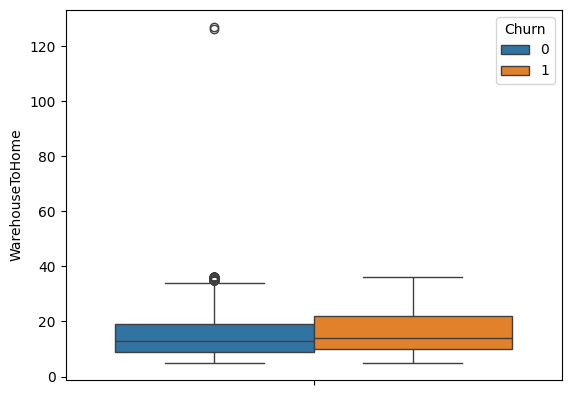

In [504]:
sns.boxplot(y=df['WarehouseToHome'],hue="Churn", data=df)

In [505]:
 df['WarehouseToHome1'] = np.log1p(df["WarehouseToHome"])


In [506]:
df['WarehouseToHome1'].skew(),df['WarehouseToHome1'].kurt()

(np.float64(0.3101704577433106), np.float64(-0.7812065182343138))

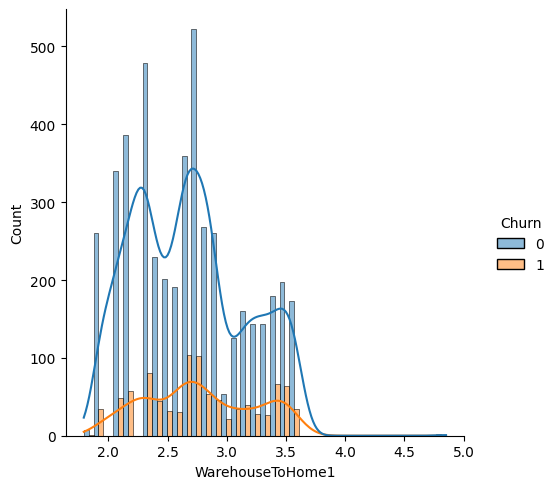

In [507]:
sns.displot(df, x="WarehouseToHome1", hue="Churn", multiple="dodge",kde=True)

<Axes: ylabel='WarehouseToHome1'>

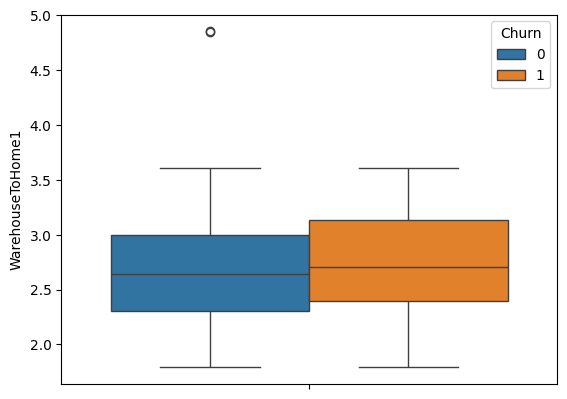

In [508]:
sns.boxplot(y=df['WarehouseToHome1'],hue="Churn", data=df)

In [509]:
# WarehouseToHome는 이상치 해소

### DaySinceLastOrder

In [510]:
df['DaySinceLastOrder'].skew(),df['DaySinceLastOrder'].kurt()

(np.float64(1.273530128531151), np.float64(4.405103273927358))

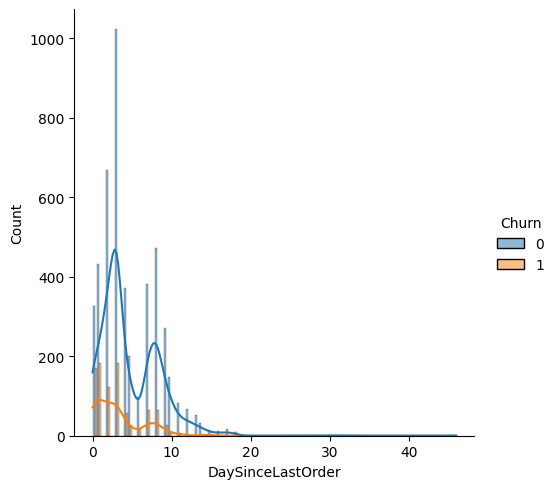

In [511]:
sns.displot(df, x="DaySinceLastOrder", hue="Churn", multiple="dodge",kde=True)

<Axes: ylabel='DaySinceLastOrder'>

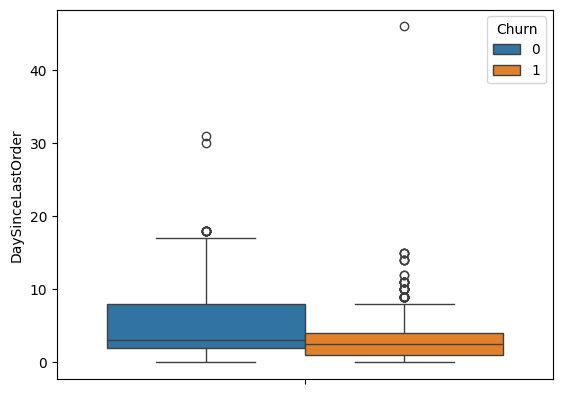

In [512]:
sns.boxplot(y=df['DaySinceLastOrder'],hue="Churn", data=df)

In [513]:
df['DaySinceLastOrder1'] = df['DaySinceLastOrder'].clip(upper=15)
# clip():일정 범위를 벗어난 값은 기준이 되는 값으로 강제로 고정
# 위의 데이터는 15이하의 값은 15로 고정
#  데이터 손실없이 극단값의 왜곡 현상을 최소화

In [514]:
df['DaySinceLastOrder1'].skew(),df['DaySinceLastOrder1'].kurt()

(np.float64(0.8448844234496463), np.float64(0.032497371955212184))

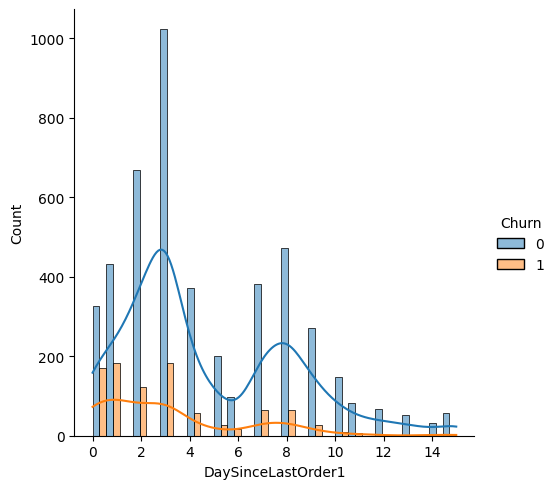

In [515]:
sns.displot(df, x="DaySinceLastOrder1", hue="Churn", multiple="dodge",kde=True)

<Axes: ylabel='DaySinceLastOrder1'>

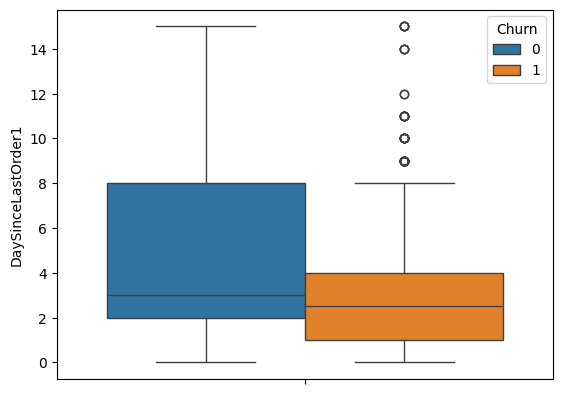

In [516]:
sns.boxplot(y=df['DaySinceLastOrder1'],hue="Churn", data=df)

### CashbackAmount

In [517]:
df['CashbackAmount'].skew(),df['CashbackAmount'].kurt()

(np.float64(1.1495949962274574), np.float64(0.9735461686576548))

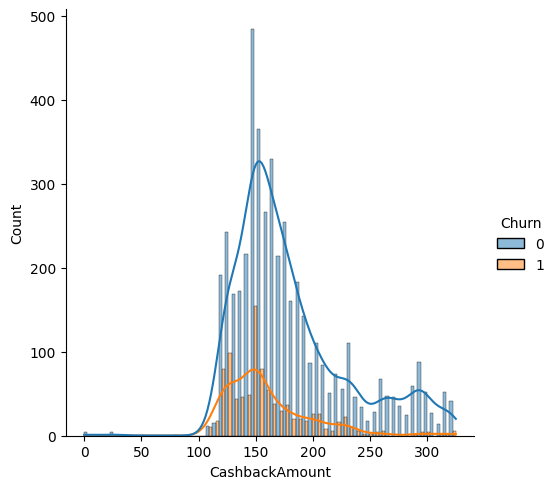

In [518]:
sns.displot(df, x="CashbackAmount", hue="Churn", multiple="dodge",kde=True)

<Axes: ylabel='CashbackAmount'>

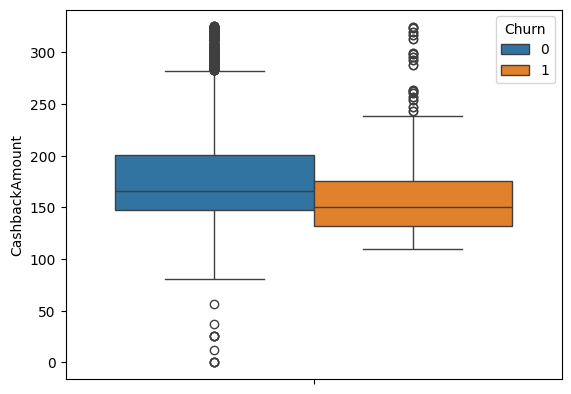

In [519]:
sns.boxplot(y=df['CashbackAmount'],hue="Churn", data=df)

In [520]:
df['CashbackAmount1'] = df['CashbackAmount'].clip(lower=100,upper=250)
# clip():일정 범위를 벗어난 값은 기준이 되는 값으로 강제로 고정
# 예를 들어 위의 데이터는 100이하의 값은 100으로 250이상의 값은 250으로 고정하여 이상치 처리
# 데이터 손실없이 극단값의 왜곡 현상을 최소화

In [521]:
df['CashbackAmount1'].skew(),df['CashbackAmount1'].kurt()

(np.float64(0.681749121680361), np.float64(-0.6016660817113468))

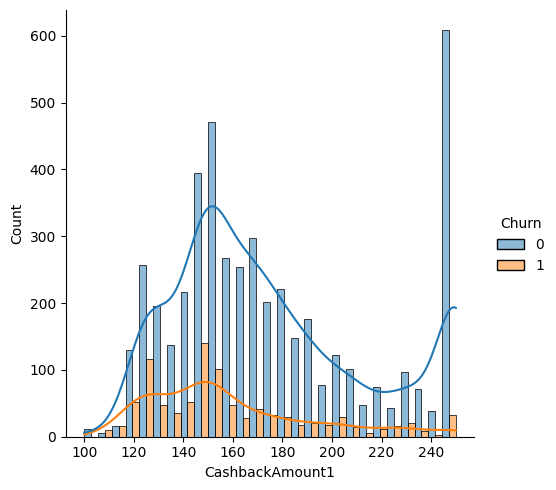

In [522]:
sns.displot(df, x="CashbackAmount1", hue="Churn", multiple="dodge",kde=True)

<Axes: ylabel='CashbackAmount1'>

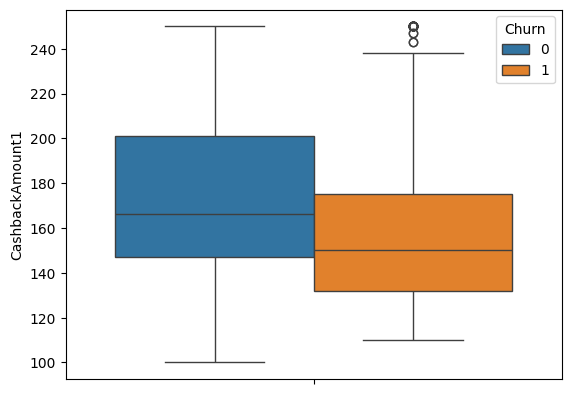

In [523]:
sns.boxplot(y=df['CashbackAmount1'],hue="Churn", data=df)

## 결론

In [524]:
def outlier_control(df,cols):


  for col in cols:
    if col == 'CashbackAmount':
      df[f'{col}_clip'] = df['CashbackAmount'].clip(lower=100,upper=240)

    elif col == 'DaySinceLastOrder':
      df[f'{col}_clip'] = df['DaySinceLastOrder'].clip(upper=18)

    else:
      df[f'{col}_log'] = np.log1p(df[col])


  df.drop(cols, axis=1, inplace=True) # 원본 피처가 필요하면 이부분 주석처리하고 사용하세요




cols=['Tenure','WarehouseToHome','DaySinceLastOrder','CashbackAmount']

outlier_control(df,cols)



In [525]:
df.drop(['Tenure1','WarehouseToHome1','DaySinceLastOrder1','CashbackAmount1'], axis=1, inplace=True)

In [526]:
df.head()

,CustomerID,Churn,PreferredLoginDevice,CityTier,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,Tenure_log,WarehouseToHome_log,DaySinceLastOrder_clip,CashbackAmount_clip
0,50001,1,Mobile Phone,3,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,1.609438,1.945910,5.0,160
1,50002,1,Phone,1,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,2.302585,2.197225,0.0,121
2,50003,1,Phone,1,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,2.302585,3.433987,3.0,120
3,50004,1,Phone,3,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,0.000000,2.772589,3.0,134
4,50005,1,Phone,1,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,0.000000,2.564949,3.0,130
